<a href="https://colab.research.google.com/github/kuhunain/PredictingGrammyWinners/blob/main/FeatureEngineering%26EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Clean Data

In [65]:
DATA_PATH = "/content/spotify-2023.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")

# clean data
df_clean = df.copy()
features = [ "in_deezer_playlists", "in_shazam_charts", "streams"] #had issues with them

# convert to numbers
df_clean[features] = (
    df_clean[features]
    .replace({',': ''}, regex=True)
    .apply(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

for col in df_clean.columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        # change any missing values to the median
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
    else:
        # change any missing to mode
        mode_val = df_clean[col].mode()
        if len(mode_val) > 0:
            df_clean[col] = df_clean[col].fillna(mode_val[0])
        else:
            df_clean[col] = df_clean[col].fillna("Unknown")

# Feature Selection

In [66]:
# === Feature Selection ===

def make_music_tempo(bpm):
  '''
  makes a music tempo category
  '''
  if pd.isna(bpm): return 'unknown'
  if bpm < 90:     return 'slow'
  if bpm < 120:    return 'medium'
  if bpm < 150:    return 'upbeat'
  return 'fast'

# ------------------------------
def make_chart_score(df):
    '''
    makes 3 chart scores for spotify, apple, and deezer for the weighted chart number
    '''

    df = df.copy()

    df['spotify_chart_score'] = df['in_spotify_charts'] / df['in_spotify_charts'].max()
    df['apple_chart_score']   = df['in_apple_charts'] / df['in_apple_charts'].max()
    df['deezer_chart_score']  = df['in_deezer_charts'] / df['in_deezer_charts'].max()

    return df

# ------------------------------
def make_stream_rank(df):
    '''
    makes a ranking for the number of streams per song
    '''

    df = df.copy()

    df['streams_rank'] = df['streams'].rank(pct=True)

    return df


# ------------------------------
# calling all
df_clean['music_tempo'] = df_clean['bpm'].apply(make_music_tempo)
df_clean = make_chart_score(df_clean)
df_clean = make_stream_rank(df_clean)

# EDA (Exploratory Data Analysis)

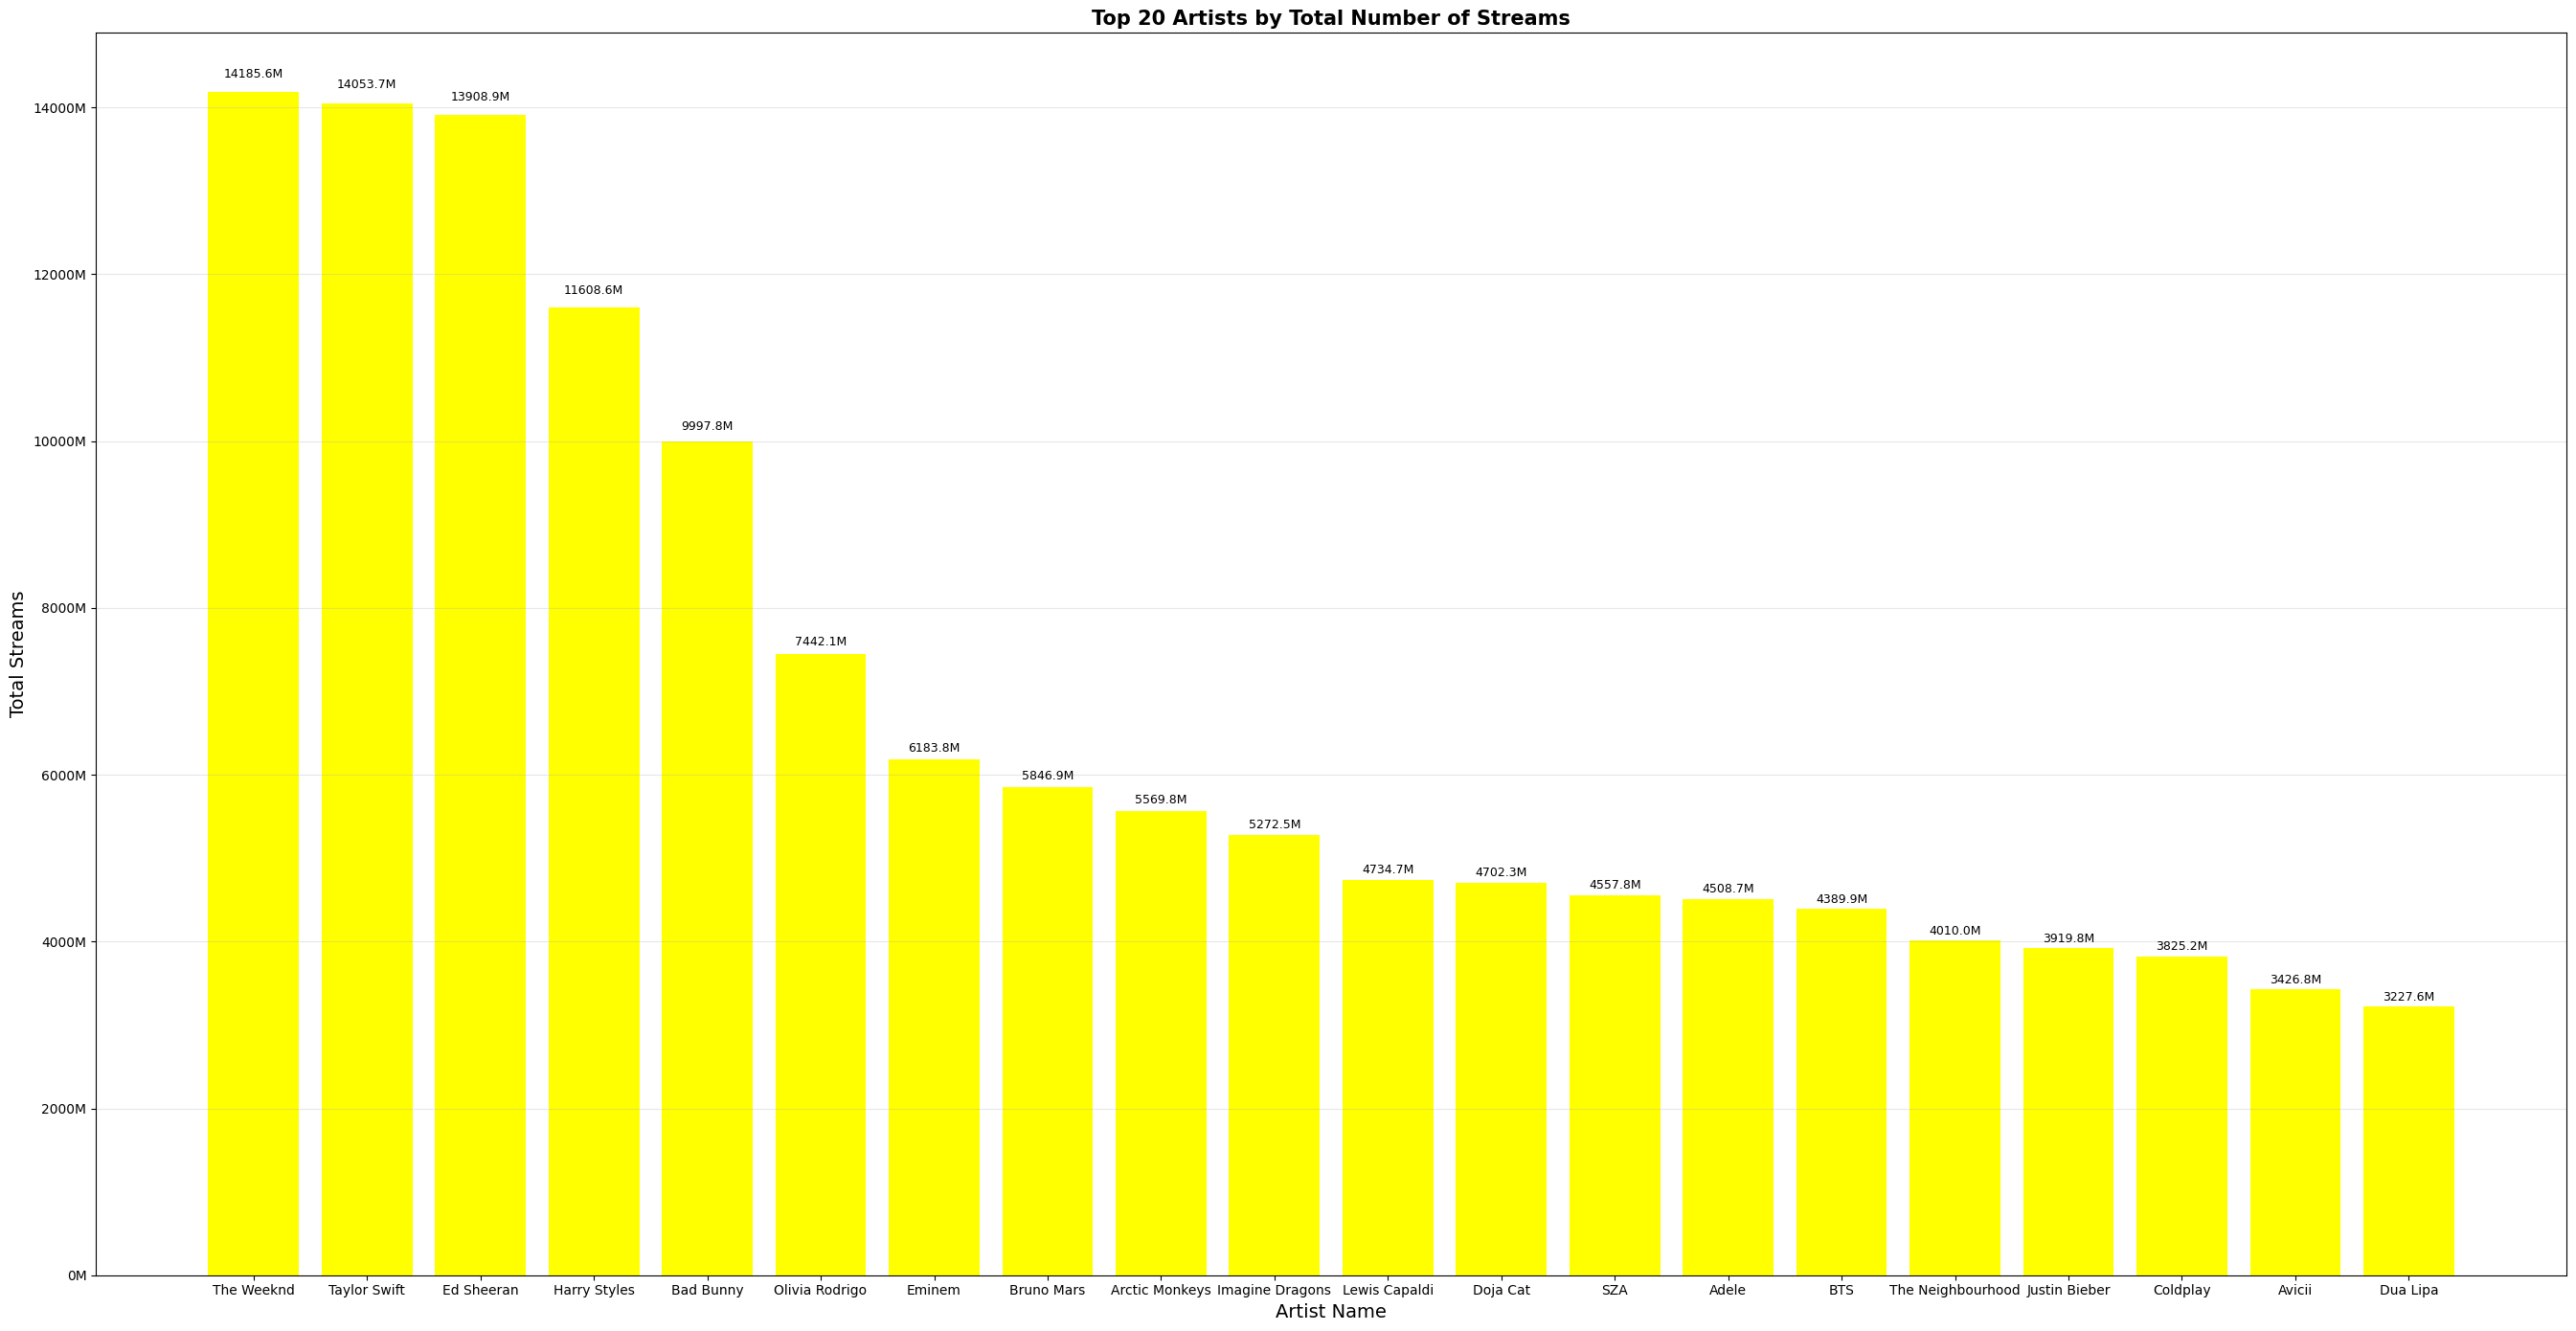

In [67]:
# Top 20 Artists ranked by streams
def plot_top_artists_by_streams(df, top_num=20):
    '''
    plots the top # (currently 20) of artists by the number of streams.

    Parameter:
    df - dataframe
    top_num - number of artists to plot
    '''
    # get the top artists by the streams column
    top_artists = df.groupby('artist(s)_name')['streams'].sum().nlargest(top_num)

    # plot
    plt.figure(figsize=(27, 14))
    all_bars = plt.bar(top_artists.index, top_artists.values, color='yellow')

    # title + axises
    plt.xlabel('Artist Name', fontsize=14)
    plt.ylabel('Total Streams', fontsize=14)
    plt.title(f'Top {top_num} Artists by Total Number of Streams', fontsize=15, fontweight='bold')

    # format y in millions since streams in milli
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e6:.0f}M'))

    # add value to bars
    for bar in all_bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + height*0.01, f'{height/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    plt.show()

# call
plot_top_artists_by_streams(df_clean)

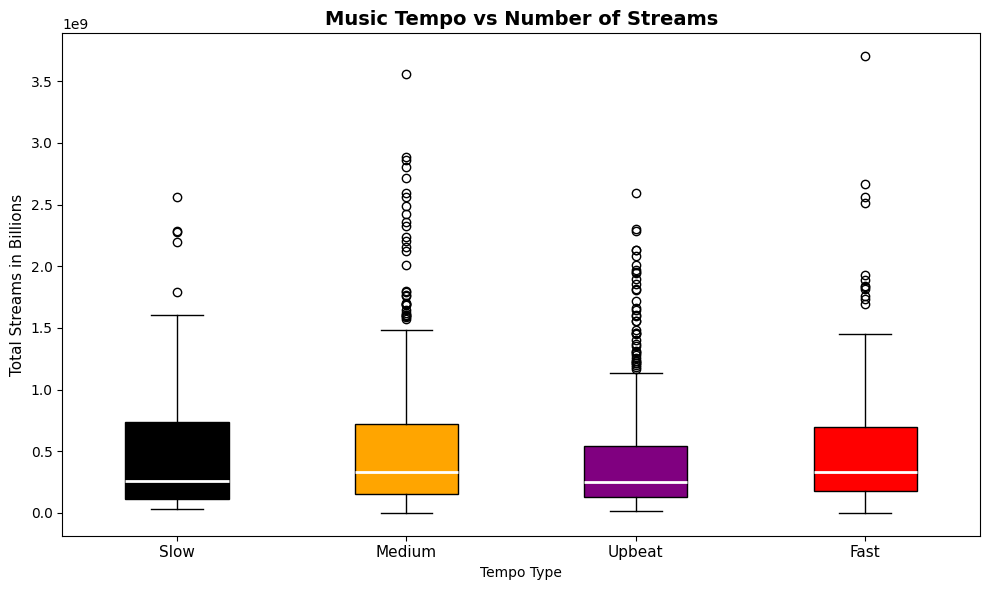

In [68]:
def plot_tempo_vs_streams(df):
    '''
    shows correlation between music tempo and number of streams

    Parameter:
    df - dataframe
    '''
    tempo_order  = ['slow', 'medium', 'upbeat', 'fast']
    tempo_colors = {'slow': 'black', 'medium': 'orange', 'upbeat': 'purple', 'fast': 'red'}

    plot_df = df[df['music_tempo'].isin(tempo_order)].copy()
    plot_df['music_tempo'] = pd.Categorical(plot_df['music_tempo'], categories=tempo_order, ordered=True)

    fig, ax = plt.subplots(figsize=(10, 6))

    # boxes
    groups = [plot_df[plot_df['music_tempo'] == t]['streams'].dropna() for t in tempo_order]
    box = ax.boxplot(groups, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))


    for patch, tempo in zip(box['boxes'], tempo_order):
        patch.set_facecolor(tempo_colors[tempo])


    ax.set_xticks(range(1, len(tempo_order) + 1))
    ax.set_xticklabels([t.capitalize() for t in tempo_order], fontsize=11)
    ax.set_xlabel('Tempo Type', fontsize=10)
    ax.set_ylabel('Total Streams in Billions', fontsize=11)
    ax.set_title('Music Tempo vs Number of Streams', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_tempo_vs_streams(df_clean)

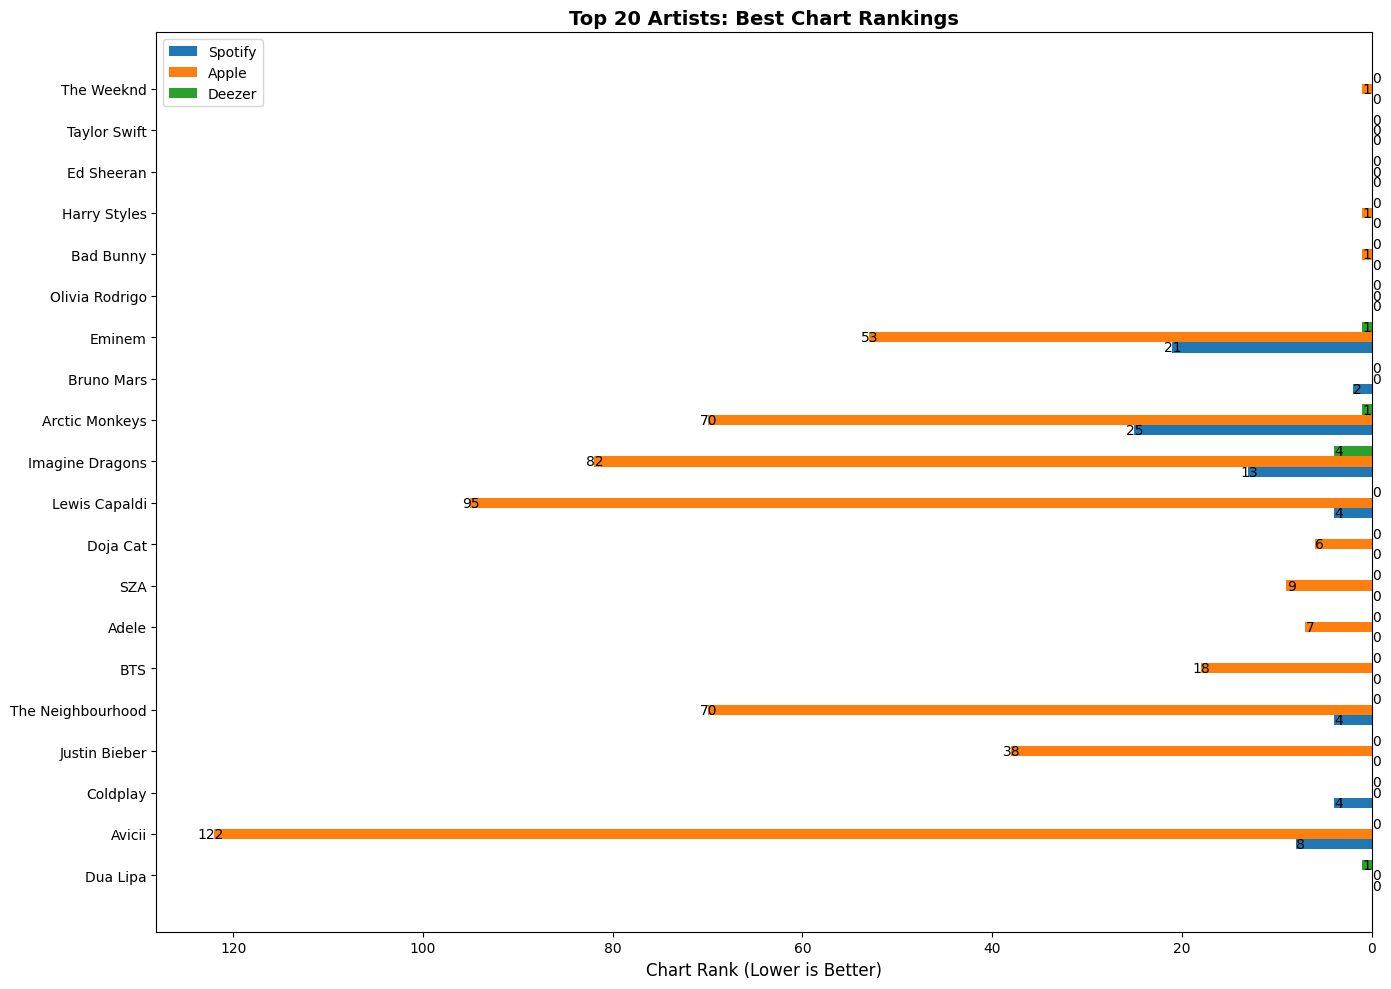

In [69]:
def plot_top_artists_vs_chart_ranks(df, top_num=20):
    spotify_rank = df.groupby('artist(s)_name')['in_spotify_charts'].min()
    apple_rank   = df.groupby('artist(s)_name')['in_apple_charts'].min()
    deezer_rank  = df.groupby('artist(s)_name')['in_deezer_charts'].min()

    # top artist by streaming
    top_artists = (
        df.groupby('artist(s)_name')['streams']
        .sum()
        .sort_values(ascending=False)
        .head(top_num)
        .index
    )

    # best artists in spotify apple and deezer
    ranks_df = pd.DataFrame({
        'Spotify': spotify_rank[top_artists],
        'Apple': apple_rank[top_artists],
        'Deezer': deezer_rank[top_artists]
    })
    ranks_df = ranks_df.iloc[::-1]
    y = np.arange(len(ranks_df))

    # change height
    fig_height = max(8, top_num * 0.5)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    bar_height = 0.25

    # make bar horizontal
    ax.barh(y - bar_height, ranks_df['Spotify'], bar_height, label='Spotify')
    ax.barh(y, ranks_df['Apple'], bar_height, label='Apple')
    ax.barh(y + bar_height, ranks_df['Deezer'], bar_height, label='Deezer')

    # labelling
    ax.set_yticks(y)
    ax.set_yticklabels(ranks_df.index)
    ax.set_xlabel('Chart Rank (Lower is Better)', fontsize=12)
    ax.set_title(f'Top {top_num} Artists: Best Chart Rankings', fontsize=14,fontweight='bold')
    ax.invert_xaxis()

    # numbers on each bar
    for i in range(len(ranks_df)):
        for col, offset in zip(['Spotify', 'Apple', 'Deezer'], [-bar_height, 0, bar_height]):
            rank = ranks_df[col].iloc[i]
            if not pd.isna(rank):
                ax.text(
                    rank - 1,
                    i + offset,
                    f'{int(rank)}',
                    va='center',
                    ha='right',
                    fontsize=10
                )

    ax.legend()
    plt.tight_layout()
    plt.show()

# call
plot_top_artists_vs_chart_ranks(df_clean)

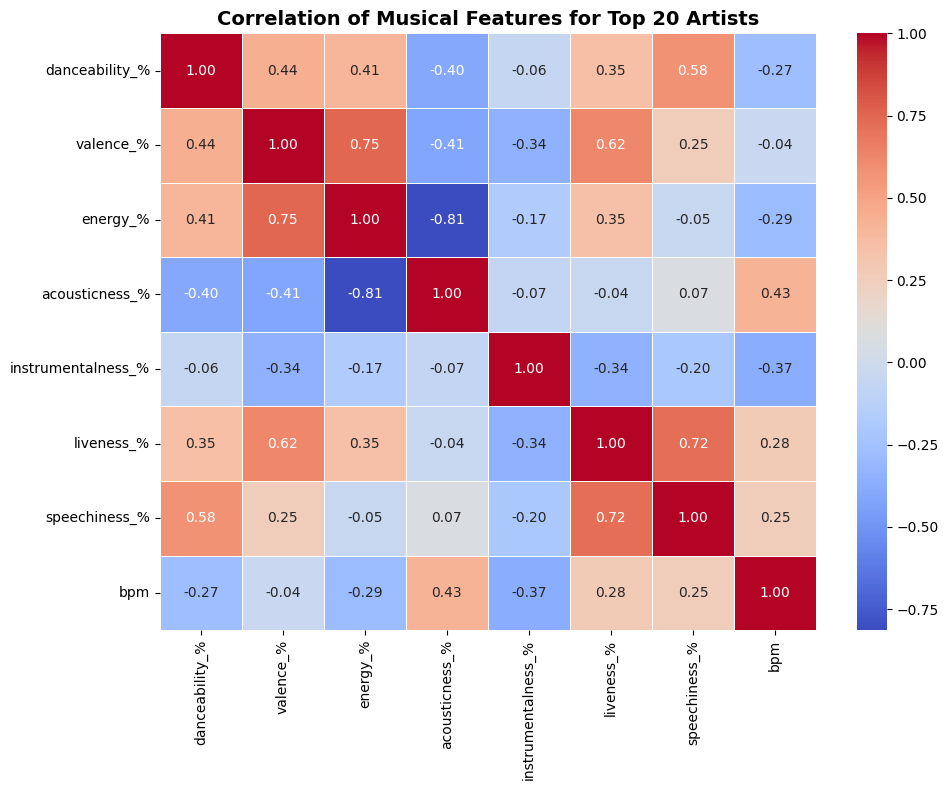

In [70]:
# Musical Features compared to top 20 Artists
def plot_musical_feature_correlation(df, top_num=20):
    '''
    plots correlation between all musical features and the top # (currently 20) artists by streams

    Parameter:
    df - dataframe
    top_num - number of top artists by streams to include
    '''
    musical_features = ["danceability_%", "valence_%", "energy_%",
                      "acousticness_%", "instrumentalness_%",
                      "liveness_%", "speechiness_%", "bpm"]

    # top artist by stream
    top_artists = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(top_num).index
    df_top = df[df['artist(s)_name'].isin(top_artists)]

    # get the mean musical feature for each artist
    df_features = df_top.groupby('artist(s)_name')[musical_features].mean()
    corr_matrix = df_features.corr()

    # plot
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title(f"Correlation of Musical Features for Top {top_num} Artists", fontsize=14, fontweight='bold')
    plt.tight_layout()

    plt.show()

# call
plot_musical_feature_correlation(df_clean)

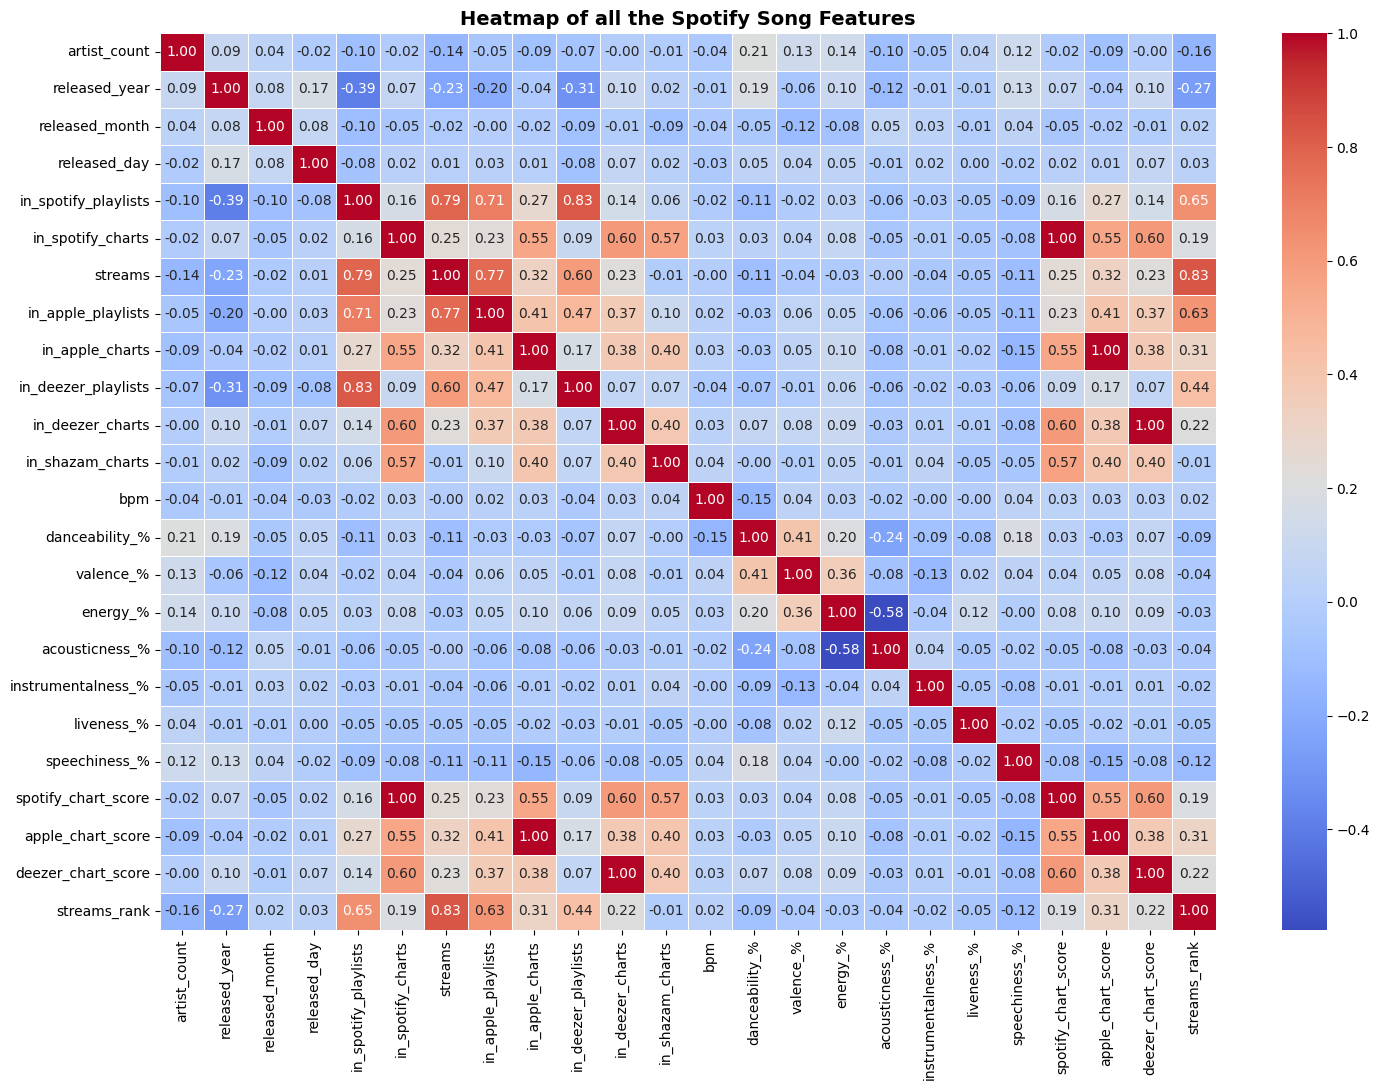

In [71]:
# Heat Map for all Attributes in csv
def plot_heat_map_all_attributes(df):
  '''
  creates a heatmap of all the attributes and shows the numerical value for each

  Parameter:
  df - dataframe
  '''
  # only get numerical values for columns
  number_df = df.select_dtypes(include=['number'])
  # finds how much each number is correlated
  corr_matrix = number_df.corr()

  # plot
  plt.figure(figsize=(15, 11))
  sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
  plt.title('Heatmap of all the Spotify Song Features', fontsize=14, fontweight='bold')
  plt.tight_layout()

  plt.show()

# call
plot_heat_map_all_attributes(df_clean)

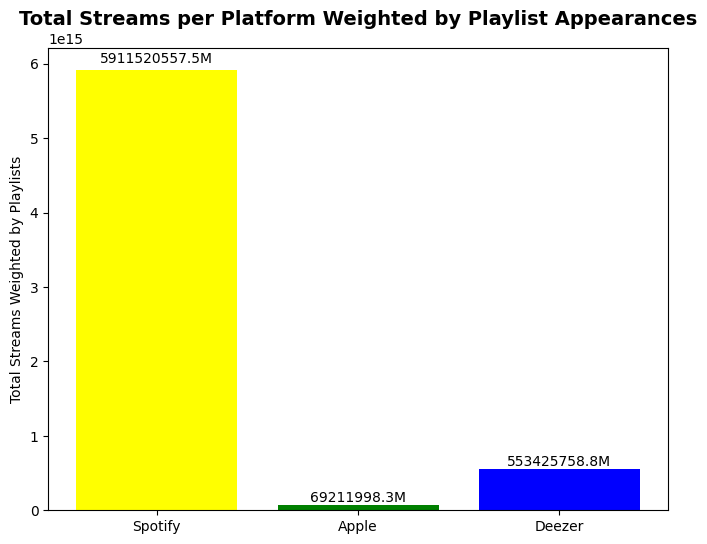

In [72]:
def plot_app_with_most_playlist(df):
  '''
  finds the app with the most amount of streamed songs -- so we can choose one to go off of

  Parameter:
  df - dataframe
  '''
  playlist_streams = {
      'Spotify': (df['streams'] * df['in_spotify_playlists']).sum(),
      'Apple': (df['streams'] * df['in_apple_playlists']).sum(),
      'Deezer': (df['streams'] * df['in_deezer_playlists']).sum()
  }

  plt.figure(figsize=(8,6))
  all_bars = plt.bar(playlist_streams.keys(), playlist_streams.values(), color=['yellow', 'green', 'blue'])

  # labelling
  for bar in all_bars:
      height = bar.get_height()
      plt.text(bar.get_x() + bar.get_width()/2, height + height*0.01, f'{height/1e6:.1f}M', ha='center', va='bottom', fontsize=10)

  plt.ylabel('Total Streams Weighted by Playlists')
  plt.title('Total Streams per Platform Weighted by Playlist Appearances', fontsize=14, fontweight="bold")
  plt.show()

#call
plot_app_with_most_playlist(df_clean)

# Discussion

**Feature Selection:**

tbd

**EDA:**

tbd